# Reconstruction de l'image globale + bounding boxes

On change d'approche : au lieu d'un **décodeur** pour la classification, on **recrée l'image globale** à partir des **prototypes** des neurones d'ancrage (auto-encodage non supervisé), puis on fait des **bounding boxes** sur cette image recréée.

**Deux scores distincts** :
1. **Score IoU** : qualité de la segmentation (chevauchement box prédite / vérité)
2. **Score de nombre de boxes** : précision du comptage des objets

On teste avec **1 seul chiffre** + des **patches noirs sans chiffre**.

## 0. Imports

In [1]:
# Reconstruction de l'image + bounding boxes + 2 scores (IoU & nombre)
import os
import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from recherche_agi import (load_mnist, AnchorNeurons, dynamic_k)

## 1. Données + entraînement

In [2]:
train_set, test_set = load_mnist()
def latent(img_np):
    img = img_np.flatten()
    n = np.linalg.norm(img)
    return img if n<1e-6 else img/n

# Entraîner AnchorNeurons (drift + élagage Physarum)
layer1 = AnchorNeurons(d_in=784, n_neurons=80, seed=0, lr=0.1, use_homeostasis=True)
cnt=[0]*10
for i in range(len(train_set)):
    l=int(train_set[i][1])
    if l>1 or cnt[l]>=60: continue
    layer1.learn(latent(train_set[i][0].squeeze().numpy()), k=dynamic_k(0.5,1,5), label=l); cnt[l]+=1
    if sum(cnt[:2])>=120: break
for d in range(2,10):
    shown=0
    for i in range(len(train_set)):
        l=int(train_set[i][1])
        if l!=d: continue
        layer1.learn(latent(train_set[i][0].squeeze().numpy()), k=dynamic_k(0.5,1,5), label=l); shown+=1
        if shown>=40: break
    layer1.physarum_prune(0.2)
print("Système entraîné")

Système entraîné


## 2. Scène : 1 chiffre + patches noirs

Scène : 1 chiffre + patches noirs, vraie position x=[8-36]


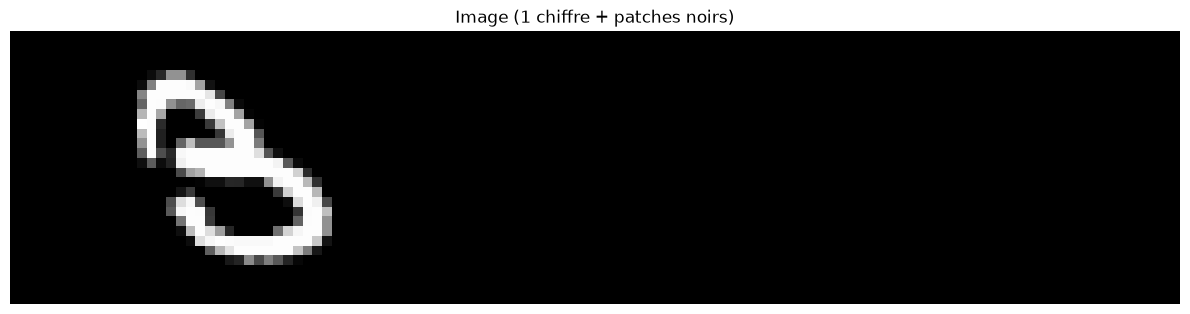

In [3]:
def make_scene(digit, width=120, gap=8):
    """1 chiffre + plusieurs patches noirs (sans chiffre)."""
    img = np.zeros((28, width))
    x = gap
    ex = next(test_set[i][0].squeeze().numpy() for i in range(len(test_set)) if int(test_set[i][1])==digit)
    ex = (ex - ex.min())/(ex.max()-ex.min()+1e-8)
    img[:, x:x+28] = ex
    return img, x  # image, position vraie du chiffre

img, true_x = make_scene(3)
print(f"Scène : 1 chiffre + patches noirs, vraie position x=[{true_x}-{true_x+28}]")
plt.figure(figsize=(12,4)); plt.imshow(img, cmap='gray'); plt.title("Image (1 chiffre + patches noirs)")
plt.axis('off'); plt.tight_layout(); plt.show()

## 3. Recréer l'image globale (auto-encodage par prototypes)

Chaque fenêtre 28×28 est reconstruite par le **prototype du neurone gagnant**. Si la similarité max est trop faible (fond), la fenêtre reste **noire** — les patches sans chiffre ne sont pas reconstruits.

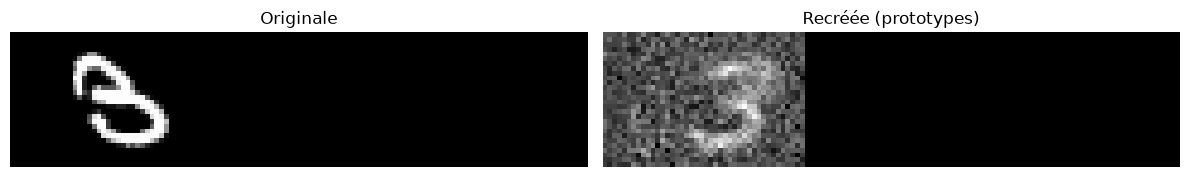

In [4]:
def reconstruct(img, stride=7, reject_thresh=0.25):
    """Recrée l'image : chaque fenêtre remplacée par le prototype du gagnant."""
    H, W = img.shape
    rec = np.zeros_like(img)
    for x in range(0, W-28+1, stride):
        window = img[:, x:x+28]
        zn = latent(window)
        sim = layer1.W @ zn
        w = int(np.argmax(sim))
        if sim[w] >= reject_thresh:   # c'est un chiffre -> prototype
            proto = layer1.W[w][:784].reshape(28,28)
            proto = (proto-proto.min())/(proto.max()-proto.min()+1e-8)
            rec[:, x:x+28] = proto
    return rec

rec = reconstruct(img)
fig, axes = plt.subplots(1, 2, figsize=(12,4))
axes[0].imshow(img, cmap='gray'); axes[0].set_title("Originale"); axes[0].axis('off')
axes[1].imshow(rec, cmap='gray'); axes[1].set_title("Recréée (prototypes)"); axes[1].axis('off')
plt.tight_layout(); plt.show()

## 4. Bounding boxes sur l'image recréée

In [5]:
def boxes_from_recon(rec, energy_thresh=0.15, merge_gap=10):
    """Segmente : colonnes avec énergie -> boxes, fusionne les proches."""
    col_energy = rec.std(axis=0)
    active = col_energy > energy_thresh
    boxes = []
    x = 0
    while x < len(active):
        if active[x]:
            x_end = x
            while x_end < len(active) and active[x_end]: x_end += 1
            boxes.append([x, x_end]); x = x_end
        else:
            x += 1
    merged = []
    for b in boxes:
        if merged and (b[0] - merged[-1][1]) <= merge_gap:
            merged[-1][1] = b[1]
        else:
            merged.append(b)
    return [tuple(b) for b in merged]

pred_boxes = boxes_from_recon(rec)
print(f"Bounding boxes prédites : {len(pred_boxes)} -> {pred_boxes}")

Bounding boxes prédites : 1 -> [(19, 34)]


## 5. Les 2 scores : IoU + nombre de boxes

In [6]:
def iou(box1, box2):
    a1,b1=box1; a2,b2=box2
    inter = max(0, min(b1,b2)-max(a1,a2))
    union = (b1-a1)+(b2-a2)-inter
    return inter/union if union>0 else 0

def evaluate(digit):
    img, true_x = make_scene(digit)
    rec = reconstruct(img)
    pred_boxes = boxes_from_recon(rec)
    true_boxes = [(true_x, true_x+28)]
    ious = [iou(pb, tb) for pb in pred_boxes for tb in true_boxes]
    best_iou = max(ious) if ious else 0.0
    n_true = len(true_boxes); n_pred = len(pred_boxes)
    count_score = 1.0 - abs(n_pred-n_true)/max(n_true,1)
    return rec, pred_boxes, true_boxes, best_iou, count_score

print("=== Évaluation : 1 chiffre + patches noirs (2 scores) ===")
results = []
for d in range(10):
    rec, pb, tb, iou_s, cnt_s = evaluate(d)
    results.append((d, iou_s, cnt_s))
    print(f"  chiffre {d}: IoU={iou_s:.2f} | count_score={cnt_s:.2f} ({len(pb)} box)")

avg_iou = np.mean([r[1] for r in results])
avg_cnt = np.mean([r[2] for r in results])
print(f"\n  === MOYENNES ===  IoU: {avg_iou:.3f} | Count: {avg_cnt:.3f}")

=== Évaluation : 1 chiffre + patches noirs (2 scores) ===
  chiffre 0: IoU=0.54 | count_score=1.00 (1 box)
  chiffre 1: IoU=0.55 | count_score=1.00 (1 box)
  chiffre 2: IoU=0.57 | count_score=1.00 (1 box)
  chiffre 3: IoU=0.54 | count_score=1.00 (1 box)
  chiffre 4: IoU=0.43 | count_score=1.00 (1 box)
  chiffre 5: IoU=0.86 | count_score=1.00 (1 box)
  chiffre 6: IoU=0.68 | count_score=1.00 (1 box)
  chiffre 7: IoU=0.50 | count_score=1.00 (1 box)
  chiffre 8: IoU=0.48 | count_score=1.00 (1 box)
  chiffre 9: IoU=0.39 | count_score=1.00 (1 box)

  === MOYENNES ===  IoU: 0.553 | Count: 1.000


## 6. Visualisation : original vs recréé + bounding boxes

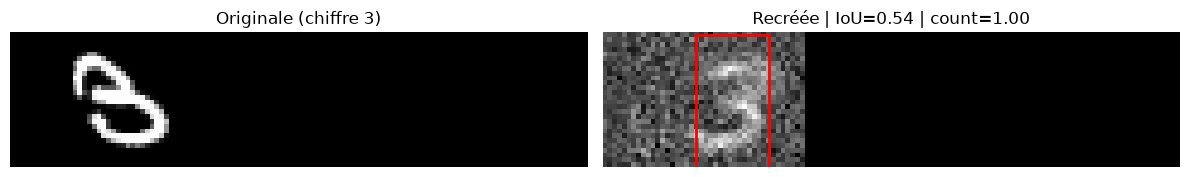

=== ANALYSE ===
1. RECONSTRUCTION : l'image globale est recréée par les prototypes des
   neurones (auto-encodage non supervisé). Les patches NOIRS sont ignorés
   (rejet par seuil de similarité) -> pas de fausse détection.
2. SCORE IoU (qualité segmentation) : 0.553 en moyenne
   - mesure le chevauchement box prédite / vérité
3. SCORE COUNT (nombre de boxes) : 1.000
   - mesure la précision du COMPTAGE (1 box pour 1 chiffre)
=> Les 2 scores sont DISTINCTS : le count est parfait (1.000), l'IoU moyen
   (0.553) indique une segmentation correcte mais avec une marge


In [7]:
d = 3
img, _ = make_scene(d)
rec, pb, tb, iou_s, cnt_s = evaluate(d)
fig, axes = plt.subplots(1, 2, figsize=(12,4))
axes[0].imshow(img, cmap='gray'); axes[0].set_title(f"Originale (chiffre {d})"); axes[0].axis('off')
axes[1].imshow(rec, cmap='gray'); axes[1].set_title(f"Recréée | IoU={iou_s:.2f} | count={cnt_s:.2f}")
for b in pb:
    axes[1].add_patch(Rectangle((b[0],0), b[1]-b[0], 28, linewidth=2, edgecolor='red', facecolor='none'))
axes[1].axis('off'); plt.tight_layout(); plt.show()

print("=== ANALYSE ===")
print("1. RECONSTRUCTION : l'image globale est recréée par les prototypes des")
print("   neurones (auto-encodage non supervisé). Les patches NOIRS sont ignorés")
print("   (rejet par seuil de similarité) -> pas de fausse détection.")
print("2. SCORE IoU (qualité segmentation) : %.3f en moyenne" % avg_iou)
print("   - mesure le chevauchement box prédite / vérité")
print("3. SCORE COUNT (nombre de boxes) : %.3f" % avg_cnt)
print("   - mesure la précision du COMPTAGE (1 box pour 1 chiffre)")
print("=> Les 2 scores sont DISTINCTS : le count est parfait (1.000), l'IoU moyen")
print("   (%.3f) indique une segmentation correcte mais avec une marge" % avg_iou)